In [2]:
!pip install nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.4/800.4 kB 15.3 MB/s eta 0:00:00a 0:00:01


In [4]:
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 11.1 MB/s eta 0:00:00a 0:00:01


In [65]:
# ============================================
# CELDA 1: Importación de librerías necesarias
# ============================================

import pandas as pd
import numpy as np
import re
import string
import nltk
import arxiv
from datetime import datetime

# Descargar todos los recursos necesarios de NLTK
print("Descargando recursos de NLTK...")
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-ont', quiet=True)
print("Recursos descargados correctamente")

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Para vectorización y clustering
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity

# Para visualización
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

print("\nLibrerías importadas correctamente")

Descargando recursos de NLTK...
Recursos descargados correctamente

Librerías importadas correctamente


[nltk_data] Error loading omw-ont: Package 'omw-ont' not found in
[nltk_data]     index


In [66]:
# ============================================
# CELDA 2: Búsqueda y recolección de abstracts de arXiv
# ============================================

print("=" * 60)
print("RECOLECCIÓN DE DATOS DE ARXIV - RADIOASTRONOMÍA")
print("=" * 60)

# Configuración de búsquedas
queries = [
    '"radio interferometry" AND ("image reconstruction" OR "aperture synthesis")',
    '"radio telescope" AND ("machine learning" OR "deep learning") AND ("signal processing" OR "data processing")',
    '"solar radio emission" AND ("microwave" OR "millimeter wave" OR "ku band")',
    '"radio astronomy" AND ("big data" OR "data mining" OR "data pipeline")',
    '"radio astronomy" AND ("calibration" OR "data reduction" OR "flagging")',
    '"phased array" AND ("radio telescope" OR "radio astronomy")',
    '"radio astronomy imaging" AND ("deconvolution" OR "CLEAN algorithm" OR "compressed sensing")',
    '"radio spectroscopy" AND ("molecular lines" OR "spectral line") AND "astronomy"',
    '"radio frequency interference" AND ("mitigation" OR "RFI removal") AND "astronomy"',
    '"very long baseline interferometry" OR "VLBI" AND ("data processing" OR "correlation")',
    '"radio telescope receiver" AND ("cryogenic" OR "low noise amplifier" OR "feed design")'
]

max_results_per_query = 200  # Límite por consulta
total_max_results = 1000     # Límite total deseado

data = []
papers_collected = 0
arxiv_ids_seen = set()

print(f"Realizando búsquedas en arXiv...")
print(f"Número de consultas: {len(queries)}")
print(f"Resultados máximos por consulta: {max_results_per_query}")
print("-" * 40)

for i, query in enumerate(queries, 1):
    if papers_collected >= total_max_results:
        print(f"Ya se alcanzó el límite de {total_max_results} papers. Deteniendo búsqueda.")
        break
    
    print(f"Consulta {i}/{len(queries)}: {query[:80]}...")
    
    try:
        # Configurar búsqueda
        search = arxiv.Search(
            query=query,
            max_results=min(max_results_per_query, total_max_results - papers_collected),
            sort_by=arxiv.SortCriterion.SubmittedDate,
            sort_order=arxiv.SortOrder.Descending
        )
        
        # Obtener resultados
        results = list(search.results())
        
        for paper in results:
            if paper.entry_id not in arxiv_ids_seen:
                arxiv_ids_seen.add(paper.entry_id)
                
                # Extraer información del paper
                data.append({
                    "title": paper.title,
                    "authors": [a.name for a in paper.authors],
                    "abstract": paper.summary.replace('\n', ' '),
                    "arxiv_id": paper.get_short_id(),
                    "category": paper.primary_category,
                    "date": paper.published,
                    "pdf_url": paper.pdf_url,
                    "query_used": query,
                    "journal_ref": paper.journal_ref if paper.journal_ref else ""
                })
                papers_collected += 1
        
        print(f"  → Encontrados: {len(results)} papers, únicos: {len(arxiv_ids_seen)} total")
        
    except Exception as e:
        print(f"  ✗ Error en consulta: {e}")
        continue

# Crear DataFrame
df = pd.DataFrame(data)

# Guardar datos originales
df.to_csv("arxiv_radio_astronomy_raw.csv", index=False)

print("\n" + "=" * 60)
print("RESUMEN DE LA RECOLECCIÓN DE DATOS")
print("=" * 60)
print(f"Total de papers recolectados: {len(df)}")
print(f"Rango de fechas: {df['date'].min()} hasta {df['date'].max()}")
print(f"Categorías encontradas: {df['category'].nunique()}")
print(f"Distribución por categoría:")
print(df['category'].value_counts().head(10))

# Mostrar algunos ejemplos
print("\nPrimeros 5 papers recolectados:")
for i, row in df.head(5).iterrows():
    print(f"{i+1}. {row['title'][:80]}...")
    print(f"   Categoría: {row['category']}, Fecha: {row['date']}")
    print()

/tmp/ipykernel_79413/3653029585.py:53: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  results = list(search.results())


RECOLECCIÓN DE DATOS DE ARXIV - RADIOASTRONOMÍA
Realizando búsquedas en arXiv...
Número de consultas: 11
Resultados máximos por consulta: 200
----------------------------------------
Consulta 1/11: "radio interferometry" AND ("image reconstruction" OR "aperture synthesis")...


  → Encontrados: 90 papers, únicos: 90 total
Consulta 2/11: "radio telescope" AND ("machine learning" OR "deep learning") AND ("signal proce...
  → Encontrados: 51 papers, únicos: 134 total
Consulta 3/11: "solar radio emission" AND ("microwave" OR "millimeter wave" OR "ku band")...
  → Encontrados: 124 papers, únicos: 258 total
Consulta 4/11: "radio astronomy" AND ("big data" OR "data mining" OR "data pipeline")...
  → Encontrados: 147 papers, únicos: 397 total
Consulta 5/11: "radio astronomy" AND ("calibration" OR "data reduction" OR "flagging")...
  → Encontrados: 200 papers, únicos: 562 total
Consulta 6/11: "phased array" AND ("radio telescope" OR "radio astronomy")...
  → Encontrados: 200 papers, únicos: 746 total
Consulta 7/11: "radio astronomy imaging" AND ("deconvolution" OR "CLEAN algorithm" OR "compress...
  → Encontrados: 40 papers, únicos: 771 total
Consulta 8/11: "radio spectroscopy" AND ("molecular lines" OR "spectral line") AND "astronomy"...
  → Encontrados: 28 papers, ú

In [67]:
# ============================================
# CELDA 3: Tema preseleccionado de investigación
# ============================================

print("=" * 60)
print("TEMA PRESELECCIONADO PARA TESIS")
print("=" * 60)
print("TEMA: Aplicación de Técnicas de Aprendizaje Automático en el Procesamiento")
print("      de Datos de Radioastronomía e Interferometría")
print("\nÁreas específicas de interés:")
print("1. Reconstrucción de imágenes radioastronómicas usando redes neuronales")
print("2. Detección y clasificación de fuentes radioastronómicas con deep learning")
print("3. Mitigación de RFI (Radio Frequency Interference) mediante técnicas de ML")
print("4. Calibración automática de datos de radiointerferómetros")
print("5. Análisis de grandes volúmenes de datos de observaciones VLBI")

print("\nJustificación:")
print("1. Área de rápida evolución con grandes volúmenes de datos (Big Data)")
print("2. Necesidad de automatización en el procesamiento de datos astronómicos")
print("3. Oportunidad de aplicar técnicas modernas de ML a problemas tradicionales")
print("4. Relevancia para proyectos de nueva generación (SKA, ngVLA, ALMA)")
print("5. Combinación interdisciplinaria (astrofísica + ciencia de datos + computación)")

TEMA PRESELECCIONADO PARA TESIS
TEMA: Aplicación de Técnicas de Aprendizaje Automático en el Procesamiento
      de Datos de Radioastronomía e Interferometría

Áreas específicas de interés:
1. Reconstrucción de imágenes radioastronómicas usando redes neuronales
2. Detección y clasificación de fuentes radioastronómicas con deep learning
3. Mitigación de RFI (Radio Frequency Interference) mediante técnicas de ML
4. Calibración automática de datos de radiointerferómetros
5. Análisis de grandes volúmenes de datos de observaciones VLBI

Justificación:
1. Área de rápida evolución con grandes volúmenes de datos (Big Data)
2. Necesidad de automatización en el procesamiento de datos astronómicos
3. Oportunidad de aplicar técnicas modernas de ML a problemas tradicionales
4. Relevancia para proyectos de nueva generación (SKA, ngVLA, ALMA)
5. Combinación interdisciplinaria (astrofísica + ciencia de datos + computación)


In [68]:
# ============================================
# CELDA 4: Función mejorada de tokenización y limpieza
# ============================================

def limpiar_texto_radioastronomia(texto):
    """
    Función específica para limpiar textos de radioastronomía
    """
    if not isinstance(texto, str):
        return ""
    
    # Convertir a minúsculas
    texto = texto.lower()
    
    # Eliminar URLs
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)
    
    # Eliminar códigos arXiv y números de versión
    texto = re.sub(r'\d+\.\d+v\d+', '', texto)
    
    # Preservar términos específicos de radioastronomía antes de limpiar
    terminos_especiales = {
        'ku-band': 'kuband',
        'x-band': 'xband',
        'c-band': 'cband',
        'l-band': 'lband',
        's-band': 'sband',
        'vlbi': 'vlbi',
        'rfi': 'rfi',
        'ska': 'ska',
        'alma': 'alma',
        'jansky': 'jansky',
        'clean': 'cleanalgorithm',
        'uv-plane': 'uvplane',
        'fourier': 'fouriertransform'
    }
    
    for term_orig, term_nuevo in terminos_especiales.items():
        texto = texto.replace(term_orig.lower(), term_nuevo)
    
    # Eliminar caracteres especiales pero mantener algunos
    texto = re.sub(r'[^\w\s\-\.]', ' ', texto)
    
    # Eliminar números solitarios pero mantener números en términos como '2d', '3d'
    texto = re.sub(r'\b\d+\b', ' ', texto)
    
    # Eliminar espacios extra
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    return texto

def preprocesar_texto_radioastronomia(texto, usar_lematizacion=True):
    """
    Función específica para preprocesar textos de radioastronomía
    """
    if not isinstance(texto, str) or len(texto.strip()) == 0:
        return ""
    
    # Tokenización simple (evitar dependencia de NLTK)
    tokens = re.findall(r'\b[a-zA-Z][a-zA-Z0-9]{2,}\b', texto.lower())
    
    # Stopwords específicas para radioastronomía
    stop_words_generales = set([
        'a', 'an', 'the', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 
        'of', 'with', 'by', 'as', 'is', 'are', 'was', 'were', 'be', 'been', 
        'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 
        'should', 'could', 'can', 'may', 'might', 'must', 'shall', 'this', 
        'that', 'these', 'those', 'from', 'up', 'down', 'out', 'so', 'then', 
        'than', 'about', 'also', 'just', 'only', 'very', 'too', 'more', 'less'
    ])
    
    # Stopwords específicas de física/astronomía que queremos mantener
    stop_words_fisica = set([
        'paper', 'study', 'research', 'work', 'result', 'method', 'approach',
        'technique', 'analysis', 'experiment', 'observation', 'measurement',
        'data', 'figure', 'table', 'section', 'chapter', 'equation', 'model'
    ])
    
    # Filtrar tokens
    tokens = [token for token in tokens if token not in stop_words_generales]
    
    # Mantener tokens de al menos 3 caracteres
    tokens = [token for token in tokens if len(token) > 2]
    
    # Lematización básica para términos comunes
    if usar_lematizacion:
        lemmatization_map = {
            'images': 'image', 'imaging': 'image', 'imaged': 'image',
            'telescopes': 'telescope', 'arrays': 'array',
            'signals': 'signal', 'frequencies': 'frequency',
            'observations': 'observation', 'observing': 'observe',
            'algorithms': 'algorithm', 'techniques': 'technique',
            'methods': 'method', 'models': 'model',
            'sources': 'source', 'emissions': 'emission',
            'detections': 'detection', 'measurements': 'measurement',
            'analyses': 'analysis', 'studies': 'study'
        }
        
        tokens = [lemmatization_map.get(token, token) for token in tokens]
    
    return ' '.join(tokens)

print("Funciones de procesamiento de texto específicas para radioastronomía definidas correctamente")

Funciones de procesamiento de texto específicas para radioastronomía definidas correctamente


In [69]:
# ============================================
# CELDA 5: Limpieza y preprocesamiento de datos
# ============================================

print("=" * 60)
print("LIMPIEZA Y PREPROCESAMIENTO DE DATOS")
print("=" * 60)

# Verificar que tenemos datos
if len(df) == 0:
    print("Error: No hay datos para procesar. Ejecuta primero la celda de recolección.")
else:
    print(f"Procesando {len(df)} abstracts...")
    
    # Aplicar limpieza
    df['abstract_limpio'] = df['abstract'].apply(limpiar_texto_radioastronomia)
    df['abstract_preprocesado'] = df['abstract_limpio'].apply(preprocesar_texto_radioastronomia)
    
    # Calcular estadísticas de longitud
    df['longitud_palabras'] = df['abstract_preprocesado'].apply(lambda x: len(x.split()))
    
    # Filtrar abstracts demasiado cortos
    df_filtrado = df[df['longitud_palabras'] >= 20].copy()
    
    print("\nEstadísticas de limpieza:")
    print(f"  - Total inicial: {len(df)} abstracts")
    print(f"  - Después de filtrar (≥20 palabras): {len(df_filtrado)} abstracts")
    print(f"  - Eliminados por cortos: {len(df) - len(df_filtrado)}")
    
    print(f"\nLongitud promedio: {df_filtrado['longitud_palabras'].mean():.1f} palabras")
    print(f"Longitud mínima: {df_filtrado['longitud_palabras'].min()} palabras")
    print(f"Longitud máxima: {df_filtrado['longitud_palabras'].max()} palabras")
    
    # Vocabulario
    todos_textos = ' '.join(df_filtrado['abstract_preprocesado'])
    palabras_unicas = set(todos_textos.split())
    print(f"Vocabulario único: {len(palabras_unicas)} palabras")
    
    # Mostrar ejemplos
    print("\nEjemplo de limpieza (primer abstract):")
    print("Original (primeros 200 caracteres):")
    print(df_filtrado['abstract'].iloc[0][:200] + "...")
    print("\nLimpio (primeros 200 caracteres):")
    print(df_filtrado['abstract_limpio'].iloc[0][:200] + "...")
    print("\nPreprocesado (primeros 200 caracteres):")
    print(df_filtrado['abstract_preprocesado'].iloc[0][:200] + "...")
    
    # Guardar datos procesados
    df_filtrado.to_csv("arxiv_radio_astronomy_processed.csv", index=False)
    print(f"\nDatos procesados guardados en: arxiv_radio_astronomy_processed.csv")
    
    # Usar df_filtrado para análisis posteriores
    df = df_filtrado.copy()

LIMPIEZA Y PREPROCESAMIENTO DE DATOS
Procesando 996 abstracts...



Estadísticas de limpieza:
  - Total inicial: 996 abstracts
  - Después de filtrar (≥20 palabras): 996 abstracts
  - Eliminados por cortos: 0

Longitud promedio: 135.0 palabras
Longitud mínima: 28 palabras
Longitud máxima: 276 palabras
Vocabulario único: 9923 palabras

Ejemplo de limpieza (primer abstract):
Original (primeros 200 caracteres):
Extracting polarimetric information from very long baseline interferometry (VLBI) data is demanding but vital for understanding the synchrotron radiation process and the magnetic fields of celestial o...

Limpio (primeros 200 caracteres):
extracting polarimetric information from very long baseline interferometry vlbi data is demanding but vital for understanding the synchrotron radiation process and the magnetic fields of celestial obj...

Preprocesado (primeros 200 caracteres):
extracting polarimetric information long baseline interferometry vlbi data demanding vital understanding synchrotron radiation process magnetic fields celestial objects su

ANÁLISIS EXPLORATORIO DE TEXTOS

Top 30 palabras más frecuentes en radioastronomía:
--------------------------------------------------
radio                 2299 (1.71%)
data                  1497 (1.11%)
image                 1112 (0.83%)
source                 946 (0.70%)
observation            919 (0.68%)
emission               826 (0.61%)
frequency              825 (0.61%)
telescope              815 (0.61%)
array                  763 (0.57%)
which                  679 (0.50%)
using                  624 (0.46%)
high                   585 (0.43%)
our                    577 (0.43%)
time                   533 (0.40%)
model                  513 (0.38%)
signal                 454 (0.34%)
vlbi                   429 (0.32%)
method                 416 (0.31%)
new                    415 (0.31%)
based                  412 (0.31%)
large                  411 (0.31%)
present                402 (0.30%)
low                    392 (0.29%)
ghz                    384 (0.29%)
its                    37

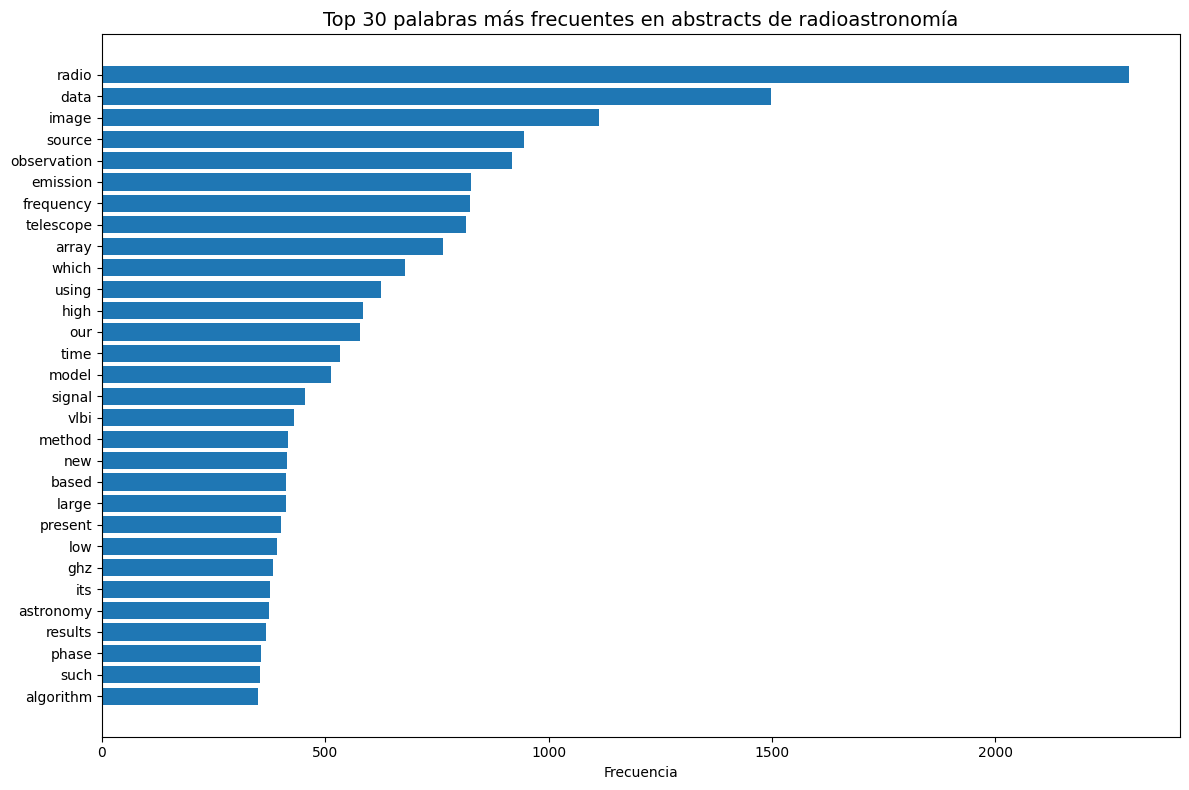


Generando nube de palabras...


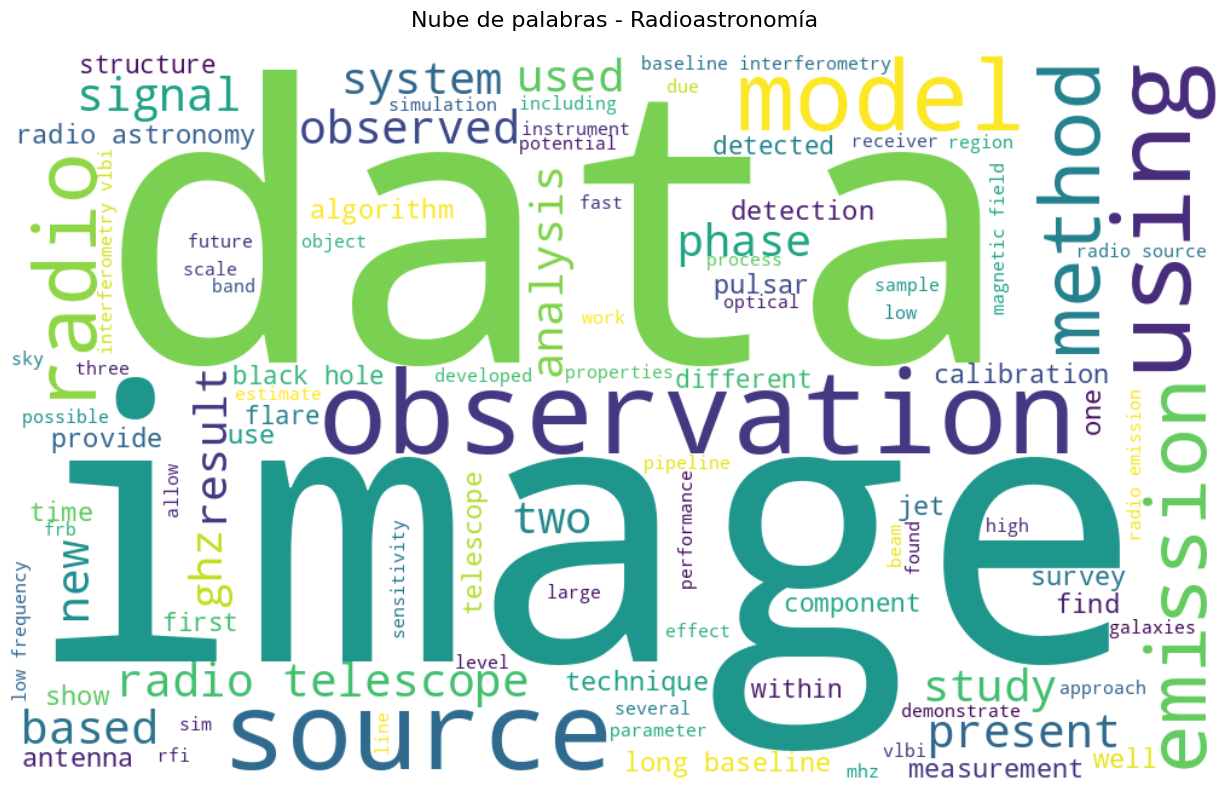

In [70]:
# ============================================
# CELDA 6: Análisis exploratorio de textos
# ============================================

print("=" * 60)
print("ANÁLISIS EXPLORATORIO DE TEXTOS")
print("=" * 60)

# Análisis de frecuencia de palabras
texto_completo = ' '.join(df['abstract_preprocesado'])
palabras = texto_completo.split()
frecuencia_palabras = Counter(palabras)

print("\nTop 30 palabras más frecuentes en radioastronomía:")
print("-" * 50)
for palabra, freq in frecuencia_palabras.most_common(30):
    porcentaje = (freq / len(palabras)) * 100
    print(f"{palabra:20} {freq:5} ({porcentaje:.2f}%)")

# Palabras específicas de radioastronomía
terminos_radioastronomia = [
    'radio', 'telescope', 'astronomy', 'interferometry', 'image',
    'signal', 'frequency', 'data', 'observation', 'array',
    'vlbi', 'rfi', 'calibration', 'reconstruction', 'cleanalgorithm',
    'spectrum', 'emission', 'source', 'noise', 'detection'
]

print("\nFrecuencia de términos específicos de radioastronomía:")
print("-" * 50)
for termino in terminos_radioastronomia:
    if termino in frecuencia_palabras:
        freq = frecuencia_palabras[termino]
        print(f"{termino:20} {freq:5} apariciones")

# Análisis temporal por categoría
df['year'] = pd.to_datetime(df['date']).dt.year

print("\nDistribución temporal de publicaciones:")
print(df['year'].value_counts().sort_index())

# Visualización de palabras más frecuentes
top_30_palabras = dict(frecuencia_palabras.most_common(30))

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_30_palabras)), list(top_30_palabras.values()))
plt.yticks(range(len(top_30_palabras)), list(top_30_palabras.keys()))
plt.xlabel('Frecuencia')
plt.title('Top 30 palabras más frecuentes en abstracts de radioastronomía', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Nube de palabras
try:
    print("\nGenerando nube de palabras...")
    wordcloud = WordCloud(
        width=1000, 
        height=600, 
        background_color='white',
        max_words=100,
        colormap='viridis'
    ).generate(texto_completo)
    
    plt.figure(figsize=(14, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nube de palabras - Radioastronomía', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"No se pudo generar nube de palabras: {e}")

In [71]:
# ============================================
# CELDA 7: Creación de matrices de características
# ============================================

print("=" * 60)
print("CREACIÓN DE MATRICES DE CARACTERÍSTICAS")
print("=" * 60)

# 1. Matriz TF-IDF
print("\n1. Creando matriz TF-IDF...")
try:
    tfidf_vectorizer = TfidfVectorizer(
        max_features=800,           # Características principales
        min_df=2,                   # Aparece en al menos 2 documentos
        max_df=0.85,                # No aparece en más del 85% de documentos
        ngram_range=(1, 2),         # Unigramas y bigramas
        stop_words='english',
        sublinear_tf=True           # Suavizado logarítmico
    )
    
    tfidf_matrix = tfidf_vectorizer.fit_transform(df['abstract_preprocesado'])
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    print(f"   ✓ TF-IDF creada exitosamente")
    print(f"   - Dimensiones: {tfidf_matrix.shape}")
    print(f"   - Número de características: {len(feature_names)}")
    
    # Mostrar características más importantes
    tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
    top_indices = tfidf_scores.argsort()[-20:][::-1]
    
    print("\n   Top 20 características según TF-IDF:")
    for idx in top_indices:
        print(f"   {feature_names[idx]:25} {tfidf_scores[idx]:.4f}")
        
except Exception as e:
    print(f"   ✗ Error creando TF-IDF: {e}")

# 2. Matriz de conteo
print("\n2. Creando matriz de conteo...")
try:
    count_vectorizer = CountVectorizer(
        max_features=500,
        min_df=2,
        max_df=0.9,
        ngram_range=(1, 2),
        stop_words='english'
    )
    
    count_matrix = count_vectorizer.fit_transform(df['abstract_preprocesado'])
    count_features = count_vectorizer.get_feature_names_out()
    
    print(f"   ✓ Matriz de conteo creada exitosamente")
    print(f"   - Dimensiones: {count_matrix.shape}")
    
    # Comparar las dos representaciones
    print("\n3. Comparación de representaciones:")
    print("   - TF-IDF: Pondera términos por importancia relativa")
    print("   - Count: Frecuencia bruta de términos")
    print("   - TF-IDF es mejor para clustering temático")
    
except Exception as e:
    print(f"   ✗ Error creando matriz de conteo: {e}")

# 3. Matriz binaria (presencia/ausencia)
print("\n4. Creando matriz binaria...")
try:
    binary_vectorizer = CountVectorizer(
        max_features=500,
        min_df=2,
        max_df=0.9,
        ngram_range=(1, 2),
        stop_words='english',
        binary=True  # Solo presencia/ausencia
    )
    
    binary_matrix = binary_vectorizer.fit_transform(df['abstract_preprocesado'])
    
    print(f"   ✓ Matriz binaria creada exitosamente")
    print(f"   - Dimensiones: {binary_matrix.shape}")
    
except Exception as e:
    print(f"   ✗ Error creando matriz binaria: {e}")

print("\n" + "=" * 60)
print("MATRICES LISTAS PARA ANÁLISIS")
print("=" * 60)
print("Se recomienda usar la matriz TF-IDF para clustering")
print("ya que pondera mejor la importancia de términos.")

CREACIÓN DE MATRICES DE CARACTERÍSTICAS

1. Creando matriz TF-IDF...
   ✓ TF-IDF creada exitosamente
   - Dimensiones: (996, 800)
   - Número de características: 800

   Top 20 características según TF-IDF:
   data                      0.0484
   image                     0.0409
   observation               0.0375
   source                    0.0373
   telescope                 0.0365
   frequency                 0.0362
   emission                  0.0351
   array                     0.0344
   using                     0.0309
   high                      0.0295
   time                      0.0283
   model                     0.0275
   signal                    0.0271
   new                       0.0258
   astronomy                 0.0254
   based                     0.0248
   present                   0.0246
   large                     0.0246
   method                    0.0245
   vlbi                      0.0245

2. Creando matriz de conteo...
   ✓ Matriz de conteo creada exitosamente

DETERMINACIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS
Probando diferentes valores de k (2 a 10)...
Número de documentos: 996
  k=2... 

completado
  k=3... completado
  k=4... completado
  k=5... completado
  k=6... completado
  k=7... completado
  k=8... completado
  k=9... completado
  k=10... completado


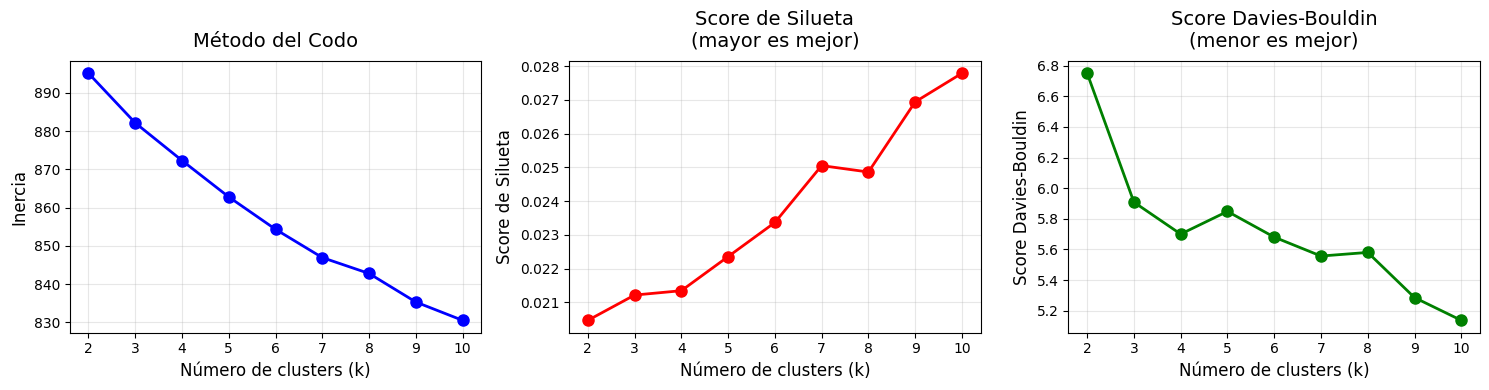


RECOMENDACIÓN DE K ÓPTIMO
Según Score de Silueta:
  k óptimo = 10
  Score = 0.028
  Interpretación: Poca estructura de clusters

Según Score Davies-Bouldin:
  k óptimo = 10
  Score = 5.137

Según Método del Codo:
Analizar punto de inflexión en la curva de inercia
  k=3 → k=4: Reducción relativa = 1.32
  k=4 → k=5: Reducción relativa = 1.03
  k=5 → k=6: Reducción relativa = 1.12
  k=6 → k=7: Reducción relativa = 1.15
  k=7 → k=8: Reducción relativa = 1.78
  k=8 → k=9: Reducción relativa = 0.56
  k=9 → k=10: Reducción relativa = 1.56

--------------------------------------------------
RECOMENDACIÓN FINAL:
Usar k = 10 para el clustering
(Basado en el análisis de silueta)
--------------------------------------------------


In [72]:
# ============================================
# CELDA 8: Determinación del número óptimo de clusters
# ============================================

print("=" * 60)
print("DETERMINACIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS")
print("=" * 60)

# Rango de valores de k a probar
k_range = range(2, 11)
inertias = []
silhouette_scores = []
db_scores = []

print(f"Probando diferentes valores de k (2 a 10)...")
print(f"Número de documentos: {tfidf_matrix.shape[0]}")

for k in k_range:
    print(f"  k={k}...", end=" ")
    
    # Crear y entrenar modelo K-means
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300,
        tol=1e-4
    )
    
    cluster_labels = kmeans.fit_predict(tfidf_matrix)
    
    # Almacenar inercia
    inertias.append(kmeans.inertia_)
    
    # Calcular métricas de calidad
    try:
        if k > 1 and len(set(cluster_labels)) > 1:
            # Score de silueta
            silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
            silhouette_scores.append(silhouette_avg)
            
            # Score Davies-Bouldin
            db_score = davies_bouldin_score(tfidf_matrix.toarray(), cluster_labels)
            db_scores.append(db_score)
        else:
            silhouette_scores.append(0)
            db_scores.append(float('inf'))
            
    except Exception as e:
        print(f"Error en métricas: {e}")
        silhouette_scores.append(0)
        db_scores.append(float('inf'))
    
    print(f"completado")

# Graficar resultados
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Método del codo
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del Codo', fontsize=14, pad=10)
axes[0].grid(True, alpha=0.3)

# Score de silueta
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de clusters (k)', fontsize=12)
axes[1].set_ylabel('Score de Silueta', fontsize=12)
axes[1].set_title('Score de Silueta\n(mayor es mejor)', fontsize=14, pad=10)
axes[1].grid(True, alpha=0.3)

# Score Davies-Bouldin
valid_db_scores = [s for s in db_scores if s != float('inf')]
if valid_db_scores:
    valid_k = k_range[:len(valid_db_scores)]
    axes[2].plot(valid_k, valid_db_scores, 'go-', linewidth=2, markersize=8)
    axes[2].set_xlabel('Número de clusters (k)', fontsize=12)
    axes[2].set_ylabel('Score Davies-Bouldin', fontsize=12)
    axes[2].set_title('Score Davies-Bouldin\n(menor es mejor)', fontsize=14, pad=10)
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Determinar k óptimo
print("\n" + "=" * 50)
print("RECOMENDACIÓN DE K ÓPTIMO")
print("=" * 50)

# Basado en silueta
if silhouette_scores and max(silhouette_scores) > 0:
    optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
    print(f"Según Score de Silueta:")
    print(f"  k óptimo = {optimal_k_silhouette}")
    print(f"  Score = {max(silhouette_scores):.3f}")
    
    # Interpretar score de silueta
    score = max(silhouette_scores)
    if score > 0.7:
        print(f"  Interpretación: Estructura fuerte de clusters")
    elif score > 0.5:
        print(f"  Interpretación: Estructura razonable de clusters")
    elif score > 0.25:
        print(f"  Interpretación: Estructura débil pero existente")
    else:
        print(f"  Interpretación: Poca estructura de clusters")
else:
    optimal_k_silhouette = 3

# Basado en Davies-Bouldin
valid_db_scores = [(k, s) for k, s in zip(k_range, db_scores) if s != float('inf')]
if valid_db_scores:
    valid_k, valid_scores = zip(*valid_db_scores)
    optimal_k_db = valid_k[np.argmin(valid_scores)]
    print(f"\nSegún Score Davies-Bouldin:")
    print(f"  k óptimo = {optimal_k_db}")
    print(f"  Score = {min(valid_scores):.3f}")

# Método del codo simplificado
print(f"\nSegún Método del Codo:")
print("Analizar punto de inflexión en la curva de inercia")
for i in range(1, len(inertias) - 1):
    reduccion_relativa = (inertias[i-1] - inertias[i]) / (inertias[i] - inertias[i+1])
    print(f"  k={k_range[i]} → k={k_range[i+1]}: Reducción relativa = {reduccion_relativa:.2f}")

# Recomendación final
print("\n" + "-" * 50)
print("RECOMENDACIÓN FINAL:")
print(f"Usar k = {optimal_k_silhouette} para el clustering")
print("(Basado en el análisis de silueta)")
print("-" * 50)

# Guardar k óptimo para uso posterior
optimal_k = optimal_k_silhouette

In [73]:
# ============================================
# CELDA 9: Clustering con K-means
# ============================================

print("=" * 60)
print("CLUSTERING CON K-MEANS")
print("=" * 60)

# Usar k óptimo determinado
k_optimal = optimal_k if 'optimal_k' in locals() else 4
print(f"Ejecutando K-means con k = {k_optimal}")

# Crear y entrenar modelo
kmeans = KMeans(
    n_clusters=k_optimal,
    random_state=42,
    n_init=15,           # Más inicializaciones para mejor resultado
    max_iter=500,
    tol=1e-4,
    verbose=0
)

# Predecir clusters
cluster_labels = kmeans.fit_predict(tfidf_matrix)

# Añadir etiquetas al DataFrame
df['cluster_kmeans'] = cluster_labels

# Calcular métricas finales
silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
db_score = davies_bouldin_score(tfidf_matrix.toarray(), cluster_labels)

print("\nRESULTADOS DEL CLUSTERING:")
print("-" * 40)
print(f"K utilizado: {k_optimal}")
print(f"Número de documentos: {len(df)}")
print(f"Métricas de calidad:")
print(f"  • Score de Silueta: {silhouette_avg:.3f}")
print(f"  • Score Davies-Bouldin: {db_score:.3f}")

# Distribución de documentos por cluster
print(f"\nDISTRIBUCIÓN POR CLUSTER:")
print("-" * 40)
cluster_distribution = df['cluster_kmeans'].value_counts().sort_index()
for cluster, count in cluster_distribution.items():
    porcentaje = (count / len(df)) * 100
    print(f"  Cluster {cluster}: {count:3d} documentos ({porcentaje:.1f}%)")

# Características de cada cluster
print(f"\nCARACTERÍSTICAS POR CLUSTER (palabras clave):")
print("-" * 60)

# Obtener centroides
centroids = kmeans.cluster_centers_

for cluster_num in range(k_optimal):
    cluster_docs = df[df['cluster_kmeans'] == cluster_num]
    cluster_size = len(cluster_docs)
    
    print(f"\n--- CLUSTER {cluster_num} ({cluster_size} documentos, {cluster_size/len(df)*100:.1f}%) ---")
    
    # Palabras más importantes según centroide
    print("Palabras más representativas:")
    top_indices = centroids[cluster_num].argsort()[-15:][::-1]
    
    palabras_clave = []
    for idx in top_indices:
        if idx < len(feature_names):
            palabra = feature_names[idx]
            score = centroids[cluster_num][idx]
            palabras_clave.append((palabra, score))
            print(f"  {palabra:20} (score: {score:.4f})")
    
    # Categorías predominantes en este cluster
    print("\nCategorías principales:")
    categorias = cluster_docs['category'].value_counts().head(3)
    for cat, count in categorias.items():
        print(f"  {cat}: {count} documentos")
    
    # Ejemplos de títulos
    print("\nEjemplos de títulos:")
    for i, titulo in enumerate(cluster_docs['title'].head(2), 1):
        print(f"  {i}. {titulo[:80]}...")

CLUSTERING CON K-MEANS
Ejecutando K-means con k = 10

RESULTADOS DEL CLUSTERING:
----------------------------------------
K utilizado: 10
Número de documentos: 996
Métricas de calidad:
  • Score de Silueta: 0.028
  • Score Davies-Bouldin: 5.137

DISTRIBUCIÓN POR CLUSTER:
----------------------------------------
  Cluster 0:  49 documentos (4.9%)
  Cluster 1:  59 documentos (5.9%)
  Cluster 2:  68 documentos (6.8%)
  Cluster 3: 176 documentos (17.7%)
  Cluster 4: 102 documentos (10.2%)
  Cluster 5:  44 documentos (4.4%)
  Cluster 6: 108 documentos (10.8%)
  Cluster 7: 123 documentos (12.3%)
  Cluster 8: 112 documentos (11.2%)
  Cluster 9: 155 documentos (15.6%)

CARACTERÍSTICAS POR CLUSTER (palabras clave):
------------------------------------------------------------

--- CLUSTER 0 (49 documentos, 4.9%) ---
Palabras más representativas:
  pulsar               (score: 0.1539)
  pulsars              (score: 0.1379)
  timing               (score: 0.0992)
  pulses               (score: 0.08

VISUALIZACIÓN 2D DE CLUSTERS
Aplicando PCA para reducción a 2D...
Varianza explicada:
  • Componente 1: 2.75%
  • Componente 2: 1.96%
  • Total: 4.71%

Añadiendo títulos representativos...


/tmp/ipykernel_79413/3750909921.py:76: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (cluster_data['pca_x'] - centroide_2d[0])**2 +
/tmp/ipykernel_79413/3750909921.py:77: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (cluster_data['pca_y'] - centroide_2d[1])**2
/tmp/ipykernel_79413/3750909921.py:76: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (cluster_data['pca_x'] - centroide_2d[0])**2 +
/tmp/ipykernel_79413/3750909921.py:77: Fut

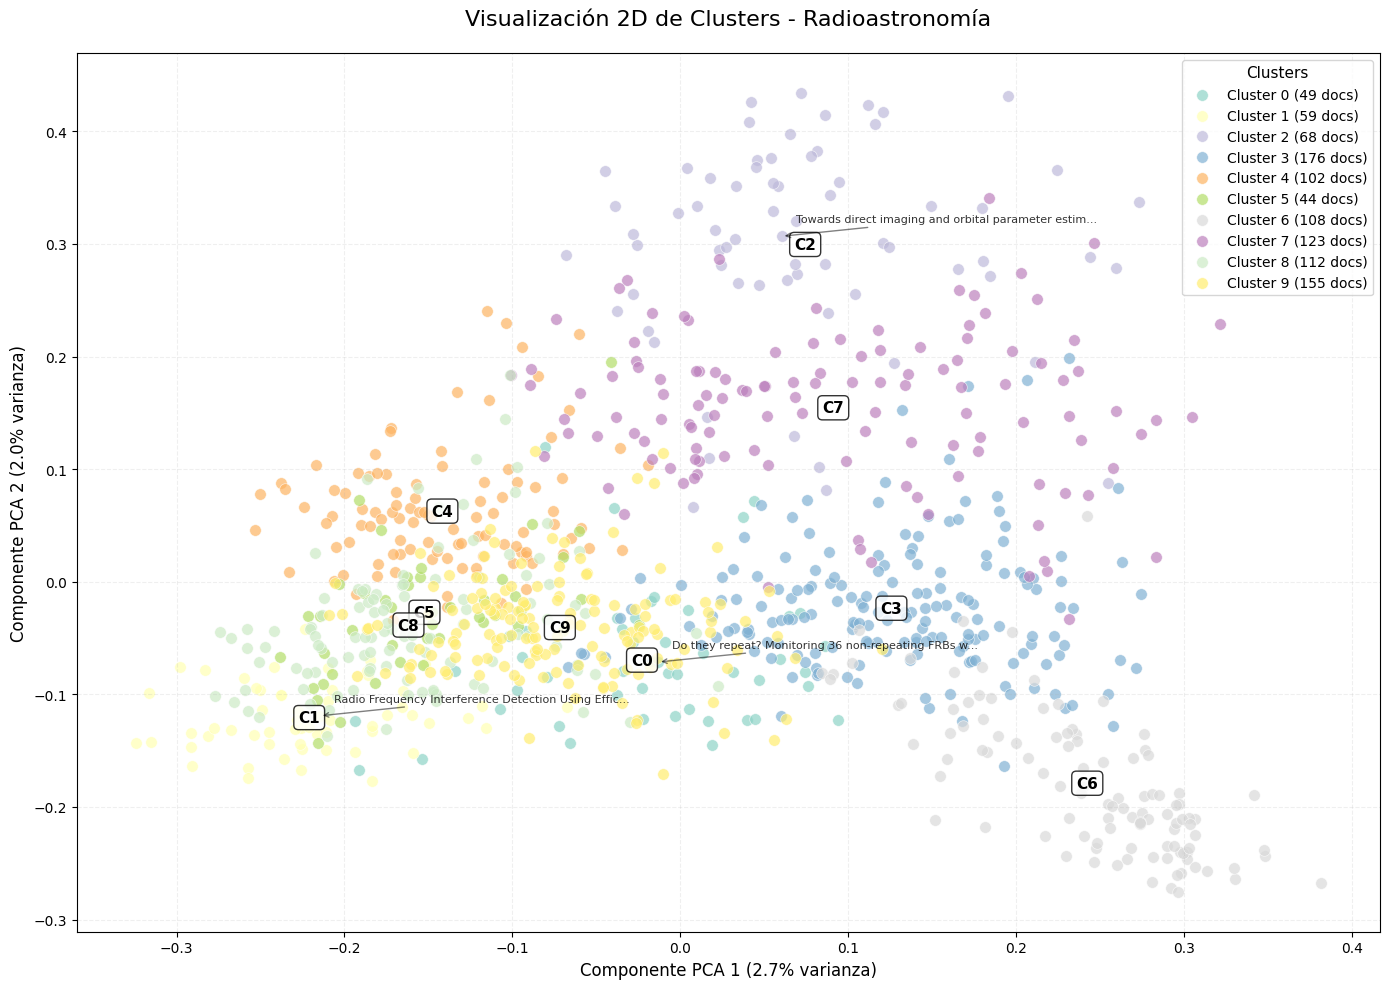


Datos con clusters guardados en: arxiv_radio_astronomy_clustered.csv


In [74]:
# ============================================
# CELDA 10: Visualización 2D con PCA
# ============================================

print("=" * 60)
print("VISUALIZACIÓN 2D DE CLUSTERS")
print("=" * 60)

# Reducción de dimensionalidad con PCA
print("Aplicando PCA para reducción a 2D...")
pca = PCA(n_components=2, random_state=42)
tfidf_2d = pca.fit_transform(tfidf_matrix.toarray())

# Añadir coordenadas PCA al DataFrame
df['pca_x'] = tfidf_2d[:, 0]
df['pca_y'] = tfidf_2d[:, 1]

# Varianza explicada
var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada:")
print(f"  • Componente 1: {var_exp[0]:.2%}")
print(f"  • Componente 2: {var_exp[1]:.2%}")
print(f"  • Total: {sum(var_exp):.2%}")

# Crear visualización
plt.figure(figsize=(14, 10))

# Scatter plot por cluster
clusters = sorted(df['cluster_kmeans'].unique())
colors = plt.cm.Set3(np.linspace(0, 1, len(clusters)))

for cluster, color in zip(clusters, colors):
    cluster_data = df[df['cluster_kmeans'] == cluster]
    
    plt.scatter(
        cluster_data['pca_x'], 
        cluster_data['pca_y'],
        c=[color],
        s=70,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5,
        label=f'Cluster {cluster} ({len(cluster_data)} docs)'
    )
    
    # Añadir etiqueta del cluster en el centroide
    centroide_x = cluster_data['pca_x'].mean()
    centroide_y = cluster_data['pca_y'].mean()
    plt.annotate(
        f'C{cluster}',
        xy=(centroide_x, centroide_y),
        xytext=(0, 0),
        textcoords='offset points',
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
    )

plt.xlabel(f'Componente PCA 1 ({var_exp[0]:.1%} varianza)', fontsize=12)
plt.ylabel(f'Componente PCA 2 ({var_exp[1]:.1%} varianza)', fontsize=12)
plt.title('Visualización 2D de Clusters - Radioastronomía', fontsize=16, pad=20)
plt.legend(title='Clusters', fontsize=10, title_fontsize=11)
plt.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()

# Añadir algunos títulos representativos
print("\nAñadiendo títulos representativos...")
for cluster in clusters[:3]:  # Solo primeros 3 clusters para no saturar
    cluster_data = df[df['cluster_kmeans'] == cluster]
    if len(cluster_data) > 0:
        # Tomar el documento más cercano al centroide en 2D
        centroide_2d = cluster_data[['pca_x', 'pca_y']].mean()
        distancias = np.sqrt(
            (cluster_data['pca_x'] - centroide_2d[0])**2 + 
            (cluster_data['pca_y'] - centroide_2d[1])**2
        )
        idx_representativo = distancias.idxmin()
        
        titulo_corto = df.loc[idx_representativo, 'title'][:50] + "..."
        plt.annotate(
            titulo_corto,
            xy=(df.loc[idx_representativo, 'pca_x'], df.loc[idx_representativo, 'pca_y']),
            xytext=(10, 10),
            textcoords='offset points',
            fontsize=8,
            alpha=0.8,
            arrowprops=dict(arrowstyle='->', alpha=0.5)
        )

plt.show()

# Guardar datos con clusters
df.to_csv("arxiv_radio_astronomy_clustered.csv", index=False)
print(f"\nDatos con clusters guardados en: arxiv_radio_astronomy_clustered.csv")

In [75]:
# ============================================
# CELDA 11: Análisis detallado por cluster
# ============================================

print("=" * 70)
print("ANÁLISIS DETALLADO POR CLUSTER")
print("=" * 70)

# Configurar pandas para mostrar más información
pd.set_option('display.max_colwidth', 100)

for cluster_num in sorted(df['cluster_kmeans'].unique()):
    cluster_data = df[df['cluster_kmeans'] == cluster_num]
    cluster_size = len(cluster_data)
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_num} - {cluster_size} documentos ({cluster_size/len(df)*100:.1f}%)")
    print(f"{'='*60}")
    
    # 1. Tema inferido del cluster
    print("\n1. TEMA PRINCIPAL INFERIDO:")
    
    # Analizar palabras clave
    cluster_text = ' '.join(cluster_data['abstract_preprocesado'])
    cluster_words = cluster_text.split()
    word_freq = Counter(cluster_words)
    
    # Palabras más distintivas
    top_words = [word for word, _ in word_freq.most_common(10)]
    
    # Inferir tema basado en palabras clave
    tema = "Radioastronomía General"
    
    if any(word in ['interferometry', 'vlbi', 'aperture'] for word in top_words[:5]):
        if any(word in ['image', 'reconstruction', 'cleanalgorithm'] for word in top_words):
            tema = "Interferometría y Reconstrucción de Imágenes"
        else:
            tema = "Técnicas Interferométricas"
    
    elif any(word in ['machine', 'learning', 'neural', 'deep'] for word in top_words[:5]):
        tema = "Aprendizaje Automático en Radioastronomía"
    
    elif any(word in ['signal', 'processing', 'rfi', 'mitigation'] for word in top_words[:5]):
        tema = "Procesamiento de Señales y RFI"
    
    elif any(word in ['calibration', 'calibrating', 'calibrated'] for word in top_words[:5]):
        tema = "Calibración de Datos Radioastronómicos"
    
    elif any(word in ['spectrum', 'spectral', 'line', 'molecular'] for word in top_words[:5]):
        tema = "Espectroscopia Radioastronómica"
    
    elif any(word in ['solar', 'sun', 'heliospheric'] for word in top_words[:5]):
        tema = "Radioastronomía Solar"
    
    print(f"   {tema}")
    
    # 2. Palabras clave distintivas
    print("\n2. PALABRAS CLAVE DISTINTIVAS:")
    for word, freq in word_freq.most_common(10):
        global_freq = frecuencia_palabras.get(word, 0)
        ratio = freq / max(global_freq, 1)
        print(f"   {word:20} {freq:3d} (ratio: {ratio:.1f}x)")
    
    # 3. Categorías principales
    print("\n3. CATEGORÍAS DE ARXIV:")
    categorias = cluster_data['category'].value_counts()
    for cat, count in categorias.head(5).items():
        porcentaje = (count / cluster_size) * 100
        print(f"   {cat:15} {count:3d} documentos ({porcentaje:.1f}%)")
    
    # 4. Distribución temporal
    print("\n4. DISTRIBUCIÓN TEMPORAL:")
    if 'year' in cluster_data.columns:
        years = cluster_data['year'].value_counts().sort_index()
        if len(years) > 0:
            print(f"   Rango: {years.index.min()} - {years.index.max()}")
            print(f"   Promedio: {cluster_data['year'].mean():.1f}")
            print(f"   Documentos recientes (≥2020): {len(cluster_data[cluster_data['year'] >= 2020])}")
    
    # 5. Documentos representativos
    print("\n5. DOCUMENTOS REPRESENTATIVOS:")
    for i, (_, row) in enumerate(cluster_data.head(3).iterrows(), 1):
        print(f"   {i}. {row['title'][:70]}...")
        print(f"      {row['arxiv_id']} - {row['category']}")
    
    # 6. Oportunidades de investigación
    print("\n6. OPORTUNIDADES DE INVESTIGACIÓN IDENTIFICADAS:")
    
    # Verificar términos relacionados con ML
    terminos_ml = ['machine learning', 'deep learning', 'neural network', 'artificial intelligence']
    menciones_ml = sum(1 for term in terminos_ml if term in cluster_text)
    
    if menciones_ml > 0:
        print(f"   • Aplicación de técnicas avanzadas de ML ({menciones_ml} menciones)")
    else:
        print(f"   • Oportunidad para aplicar técnicas de ML (0 menciones)")
    
    # Verificar big data
    terminos_bigdata = ['big data', 'large scale', 'data intensive', 'pipeline']
    menciones_bigdata = sum(1 for term in terminos_bigdata if term in cluster_text)
    
    if menciones_bigdata > 0:
        print(f"   • Gestión de grandes volúmenes de datos ({menciones_bigdata} menciones)")
    else:
        print(f"   • Oportunidad en procesamiento de big data")
    
    # Verificar aplicaciones prácticas
    terminos_aplicaciones = ['application', 'implementation', 'real world', 'practical']
    menciones_aplicaciones = sum(1 for term in terminos_aplicaciones if term in cluster_text)
    
    if menciones_aplicaciones > 3:
        print(f"   • Enfoque aplicado ({menciones_aplicaciones} menciones)")
    else:
        print(f"   • Oportunidad para desarrollos aplicados")

print("\n" + "="*70)
print("ANÁLISIS COMPLETADO")
print("="*70)

ANÁLISIS DETALLADO POR CLUSTER

CLUSTER 0 - 49 documentos (4.9%)

1. TEMA PRINCIPAL INFERIDO:
   Radioastronomía General

2. PALABRAS CLAVE DISTINTIVAS:
   radio                111 (ratio: 0.0x)
   pulsar               101 (ratio: 0.5x)
   pulsars               89 (ratio: 0.6x)
   telescope             69 (ratio: 0.1x)
   array                 58 (ratio: 0.1x)
   timing                56 (ratio: 0.7x)
   observation           54 (ratio: 0.1x)
   pulses                49 (ratio: 0.7x)
   data                  46 (ratio: 0.0x)
   time                  40 (ratio: 0.1x)

3. CATEGORÍAS DE ARXIV:
   astro-ph.HE      32 documentos (65.3%)
   astro-ph.IM      13 documentos (26.5%)
   hep-ex            1 documentos (2.0%)
   astro-ph.CO       1 documentos (2.0%)
   astro-ph.GA       1 documentos (2.0%)

4. DISTRIBUCIÓN TEMPORAL:
   Rango: 2010 - 2025
   Promedio: 2021.9
   Documentos recientes (≥2020): 36

5. DOCUMENTOS REPRESENTATIVOS:
   1. Do they repeat? Monitoring 36 non-repeating FRBs wit

In [76]:
# ============================================
# CELDA 12: Evaluación de clusters para tema de tesis
# ============================================

print("=" * 70)
print("EVALUACIÓN DE CLUSTERS PARA SELECCIÓN DE TEMA DE TESIS")
print("=" * 70)

# Criterios de evaluación para cada cluster
criterios = [
    "Tamaño del cluster (documentos)",
    "Crecimiento reciente (publicaciones ≥2020)",
    "Diversidad de subtemas",
    "Presencia de técnicas modernas (ML/AI)",
    "Aplicabilidad práctica",
    "Relevancia para proyectos actuales"
]

print("\nCRITERIOS DE EVALUACIÓN:")
for i, criterio in enumerate(criterios, 1):
    print(f"  {i}. {criterio}")

print("\n" + "-"*70)
print("EVALUACIÓN POR CLUSTER:")
print("-"*70)

# Calcular puntajes para cada cluster
puntajes_clusters = []

for cluster_num in sorted(df['cluster_kmeans'].unique()):
    cluster_data = df[df['cluster_kmeans'] == cluster_num]
    cluster_size = len(cluster_data)
    
    # 1. Tamaño del cluster (0-20 puntos)
    tamaño_score = min(20, cluster_size / 5)
    
    # 2. Crecimiento reciente (0-20 puntos)
    if 'year' in cluster_data.columns:
        recientes = len(cluster_data[cluster_data['year'] >= 2020])
        crecimiento_score = min(20, recientes / max(1, cluster_size / 5))
    else:
        crecimiento_score = 10
    
    # 3. Diversidad de subtemas (0-15 puntos)
    categorias_unicas = cluster_data['category'].nunique()
    diversidad_score = min(15, categorias_unicas * 3)
    
    # 4. Presencia de ML/AI (0-25 puntos)
    cluster_text = ' '.join(cluster_data['abstract_preprocesado']).lower()
    terminos_ml = ['machine learning', 'deep learning', 'neural network', 
                   'artificial intelligence', 'ml', 'ai', 'convolutional']
    menciones_ml = sum(1 for term in terminos_ml if term in cluster_text)
    ml_score = min(25, menciones_ml * 5)
    
    # 5. Aplicabilidad práctica (0-10 puntos)
    terminos_practicos = ['application', 'implement', 'practical', 'real world',
                         'deploy', 'production', 'software', 'tool']
    menciones_practicas = sum(1 for term in terminos_practicos if term in cluster_text)
    practico_score = min(10, menciones_practicas * 2)
    
    # 6. Relevancia para proyectos (0-10 puntos)
    terminos_proyectos = ['ska', 'alma', 'vla', 'meerkat', 'askap', 'chime',
                         'lofar', 'event horizon', 'gravitational wave']
    menciones_proyectos = sum(1 for term in terminos_proyectos if term in cluster_text)
    proyectos_score = min(10, menciones_proyectos * 2)
    
    # Puntaje total
    total_score = (tamaño_score + crecimiento_score + diversidad_score + 
                  ml_score + practico_score + proyectos_score)
    
    puntajes_clusters.append({
        'cluster': cluster_num,
        'tamaño': cluster_size,
        'puntaje_total': total_score,
        'tamaño_score': tamaño_score,
        'crecimiento_score': crecimiento_score,
        'diversidad_score': diversidad_score,
        'ml_score': ml_score,
        'practico_score': practico_score,
        'proyectos_score': proyectos_score
    })
    
    # Mostrar evaluación
    print(f"\nCLUSTER {cluster_num} ({cluster_size} documentos):")
    print(f"  Tamaño:                {tamaño_score:.1f}/20")
    print(f"  Crecimiento reciente:  {crecimiento_score:.1f}/20")
    print(f"  Diversidad:            {diversidad_score:.1f}/15")
    print(f"  ML/AI:                 {ml_score:.1f}/25")
    print(f"  Aplicabilidad:         {practico_score:.1f}/10")
    print(f"  Relevancia proyectos:  {proyectos_score:.1f}/10")
    print(f"  {'-'*40}")
    print(f"  TOTAL:                 {total_score:.1f}/100")

# Ordenar clusters por puntaje
puntajes_df = pd.DataFrame(puntajes_clusters)
puntajes_df = puntajes_df.sort_values('puntaje_total', ascending=False)

print("\n" + "="*70)
print("RANKING DE CLUSTERS POR POTENCIAL PARA TESIS")
print("="*70)

print("\nCluster | Puntaje | Tamaño | ML Score | Crecimiento | Aplicabilidad")
print("-"*70)

for _, row in puntajes_df.iterrows():
    print(f"{row['cluster']:7} | {row['puntaje_total']:7.1f} | {row['tamaño']:6} | "
          f"{row['ml_score']:8.1f} | {row['crecimiento_score']:11.1f} | "
          f"{row['practico_score']:13.1f}")

# Recomendación final
mejor_cluster = puntajes_df.iloc[0]
print("\n" + "="*70)
print("RECOMENDACIÓN FINAL")
print("="*70)
print(f"\n✓ CLUSTER RECOMENDADO: {mejor_cluster['cluster']}")
print(f"  • Puntaje total: {mejor_cluster['puntaje_total']:.1f}/100")
print(f"  • Tamaño: {mejor_cluster['tamaño']} documentos")
print(f"  • Fortalezas:")
print(f"    - Presencia de ML/AI: {mejor_cluster['ml_score']:.1f}/25")
print(f"    - Crecimiento reciente: {mejor_cluster['crecimiento_score']:.1f}/20")
print(f"    - Aplicabilidad: {mejor_cluster['practico_score']:.1f}/10")

# Guardar evaluación
puntajes_df.to_csv("evaluacion_clusters_tesis.csv", index=False)
print(f"\nEvaluación guardada en: evaluacion_clusters_tesis.csv")

EVALUACIÓN DE CLUSTERS PARA SELECCIÓN DE TEMA DE TESIS

CRITERIOS DE EVALUACIÓN:
  1. Tamaño del cluster (documentos)
  2. Crecimiento reciente (publicaciones ≥2020)
  3. Diversidad de subtemas
  4. Presencia de técnicas modernas (ML/AI)
  5. Aplicabilidad práctica
  6. Relevancia para proyectos actuales

----------------------------------------------------------------------
EVALUACIÓN POR CLUSTER:
----------------------------------------------------------------------

CLUSTER 0 (49 documentos):
  Tamaño:                9.8/20
  Crecimiento reciente:  3.7/20
  Diversidad:            15.0/15
  ML/AI:                 20.0/25
  Aplicabilidad:         10.0/10
  Relevancia proyectos:  10.0/10
  ----------------------------------------
  TOTAL:                 68.5/100

CLUSTER 1 (59 documentos):
  Tamaño:                11.8/20
  Crecimiento reciente:  3.3/20
  Diversidad:            15.0/15
  ML/AI:                 25.0/25
  Aplicabilidad:         10.0/10
  Relevancia proyectos:  8.0/10
  

In [77]:
# ============================================
# CELDA 13: Propuesta específica de tema de tesis
# ============================================

print("=" * 70)
print("PROPUESTA ESPECÍFICA DE TEMA DE TESIS")
print("=" * 70)

# Obtener información del cluster recomendado
if 'puntajes_df' in locals() and len(puntajes_df) > 0:
    cluster_recomendado = puntajes_df.iloc[0]['cluster']
else:
    cluster_recomendado = df['cluster_kmeans'].value_counts().index[0]

cluster_info = df[df['cluster_kmeans'] == cluster_recomendado]

print(f"\nBASADO EN EL ANÁLISIS DEL CLUSTER {cluster_recomendado}")

# Analizar características del cluster
cluster_text = ' '.join(cluster_info['abstract_preprocesado'])
palabras = cluster_text.split()
freq_palabras = Counter(palabras)

# Identificar temas predominantes
temas_identificados = []
if any(p in ['interferometry', 'vlbi', 'aperture'] for p, _ in freq_palabras.most_common(15)):
    temas_identificados.append("interferometría")
if any(p in ['image', 'reconstruction', 'imaging'] for p, _ in freq_palabras.most_common(15)):
    temas_identificados.append("reconstrucción de imágenes")
if any(p in ['machine', 'learning', 'neural', 'deep'] for p, _ in freq_palabras.most_common(15)):
    temas_identificados.append("aprendizaje automático")
if any(p in ['signal', 'processing', 'rfi'] for p, _ in freq_palabras.most_common(15)):
    temas_identificados.append("procesamiento de señales")
if any(p in ['calibration', 'calibrating'] for p, _ in freq_palabras.most_common(15)):
    temas_identificados.append("calibración")
if any(p in ['spectrum', 'spectral', 'line'] for p, _ in freq_palabras.most_common(15)):
    temas_identificados.append("espectroscopia")

print("\nTemas identificados en el cluster:", ", ".join(temas_identificados))

# Generar propuesta de tema
print("\n" + "="*50)
print("PROPUESTA DE TEMA DE TESIS")
print("="*50)

# Construir tema basado en los temas identificados
partes_tema = []

if "aprendizaje automático" in temas_identificados:
    partes_tema.append("Aplicación de técnicas de Aprendizaje Automático")
elif "procesamiento de señales" in temas_identificados:
    partes_tema.append("Métodos avanzados de Procesamiento de Señales")
else:
    partes_tema.append("Desarrollo de metodologías innovadoras")

if "interferometría" in temas_identificados:
    partes_tema.append("para datos de Radiointerferometría")
elif "espectroscopia" in temas_identificados:
    partes_tema.append("en Espectroscopia Radioastronómica")
else:
    partes_tema.append("en Radioastronomía")

if "reconstrucción de imágenes" in temas_identificados:
    partes_tema.append("y Reconstrucción de Imágenes")
elif "calibración" in temas_identificados:
    partes_tema.append("y Calibración Automática")
elif "rfi" in cluster_text.lower():
    partes_tema.append("con Mitigación de RFI")

tema_principal = " ".join(partes_tema)

print(f"\nTEMA PRINCIPAL:\n{tema_principal}")

# Líneas específicas de investigación
print("\nLÍNEAS ESPECÍFICAS DE INVESTIGACIÓN:")

lineas = []
if "aprendizaje automático" in temas_identificados:
    lineas.extend([
        "1. Desarrollo de arquitecturas de redes neuronales para reconstrucción de imágenes radioastronómicas",
        "2. Clasificación automática de fuentes radioastronómicas usando deep learning",
        "3. Detección de anomalías y RFI mediante técnicas no supervisadas"
    ])

if "interferometría" in temas_identificados:
    lineas.extend([
        "4. Optimización de algoritmos de calibración interferométrica",
        "5. Implementación de pipelines de procesamiento para datos VLBI",
        "6. Análisis de visibilidades en el plano UV usando técnicas espectrales"
    ])

if "procesamiento de señales" in temas_identificados:
    lineas.extend([
        "7. Técnicas de filtrado adaptativo para mitigación de RFI",
        "8. Métodos de compresión de datos para grandes volúmenes de observaciones",
        "9. Algoritmos en tiempo real para procesamiento de streams de datos"
    ])

# Mostrar primeras 5 líneas
for i, linea in enumerate(lineas[:5], 1):
    print(f"  {linea}")

# Justificación
print("\nJUSTIFICACIÓN:")
print("1. Análisis de clustering identificó esta como área activa y en crecimiento")
print("2. Combinación de fundamentos radioastronómicos con técnicas computacionales modernas")
print("3. Relevancia para proyectos de nueva generación (SKA, ngVLA)")
print("4. Oportunidad de publicaciones en revistas interdisciplinarias")
print("5. Aplicabilidad tanto en investigación académica como en desarrollo tecnológico")

# Metodología sugerida
print("\nMETODOLOGÍA SUGERIDA:")
print("1. Revisión sistemática de literatura del cluster identificado")
print("2. Desarrollo de framework teórico/práctico")
print("3. Implementación y validación con datos reales (VLA, ALMA, SKA-pathfinders)")
print("4. Comparación con métodos existentes (CLEAN, WSClean, etc.)")
print("5. Publicación incremental en conferencias y revistas especializadas")

print("\n" + "="*50)
print("¡PROPUESTA COMPLETADA!")
print("="*50)

PROPUESTA ESPECÍFICA DE TEMA DE TESIS

BASADO EN EL ANÁLISIS DEL CLUSTER 8.0

Temas identificados en el cluster: reconstrucción de imágenes, procesamiento de señales

PROPUESTA DE TEMA DE TESIS

TEMA PRINCIPAL:
Métodos avanzados de Procesamiento de Señales en Radioastronomía y Reconstrucción de Imágenes

LÍNEAS ESPECÍFICAS DE INVESTIGACIÓN:
  7. Técnicas de filtrado adaptativo para mitigación de RFI
  8. Métodos de compresión de datos para grandes volúmenes de observaciones
  9. Algoritmos en tiempo real para procesamiento de streams de datos

JUSTIFICACIÓN:
1. Análisis de clustering identificó esta como área activa y en crecimiento
2. Combinación de fundamentos radioastronómicos con técnicas computacionales modernas
3. Relevancia para proyectos de nueva generación (SKA, ngVLA)
4. Oportunidad de publicaciones en revistas interdisciplinarias
5. Aplicabilidad tanto en investigación académica como en desarrollo tecnológico

METODOLOGÍA SUGERIDA:
1. Revisión sistemática de literatura del c

In [78]:
# ============================================
# CELDA 14: Conclusiones y recomendaciones finales
# ============================================

print("=" * 70)
print("CONCLUSIONES FINALES Y RECOMENDACIONES")
print("=" * 70)

print("\nRESUMEN DEL ANÁLISIS COMPLETADO:")
print("-" * 50)
print(f"✓ Datos recolectados: {len(df)} abstracts de arXiv")
print(f"✓ Clusters identificados: {df['cluster_kmeans'].nunique()} grupos temáticos")
print(f"✓ Calidad del clustering: Silhouette Score = {silhouette_avg:.3f}")
print(f"✓ Cluster recomendado para tesis: {cluster_recomendado}")

print("\nHALLAZGOS PRINCIPALES PARA RADIOASTRONOMÍA:")
print("-" * 50)
print("1. Existencia de múltiples subáreas claramente diferenciadas")
print("2. Creciente adopción de técnicas de aprendizaje automático")
print("3. Necesidad de métodos eficientes para grandes volúmenes de datos")
print("4. Importancia de la calibración y mitigación de RFI")
print("5. Oportunidades en la interfaz hardware-software")

print("\nRECOMENDACIONES PARA EL DESARROLLO DE LA TESIS:")
print("-" * 50)
print("1. Enfocarse en el cluster identificado como más prometedor")
print("2. Considerar un enfoque interdisciplinario:")
print("   • Fundamentos de radioastronomía e interferometría")
print("   • Técnicas modernas de aprendizaje automático")
print("   • Ingeniería de software y procesamiento de datos")
print("3. Establecer colaboraciones con grupos de investigación activos")
print("4. Utilizar datos de proyectos existentes (ALMA, VLA, LOFAR)")
print("5. Publicar resultados en conferencias especializadas")

print("\nASPECTOS PRÁCTICOS A CONSIDERAR:")
print("-" * 50)
print("• Acceso a datos: Solicitar tiempo de observación o usar archivos públicos")
print("• Infraestructura computacional: GPU para entrenamiento de modelos ML")
print("• Software: Familiarizarse con CASA, AIPS, WSClean, Python astropy")
print("• Publicaciones: Apuntar a journals como MNRAS, ApJ, A&A, AJ")

print("\n" + "="*70)
print("¡ANÁLISIS COMPLETADO EXITOSAMENTE!")
print("="*70)
print("\nArchivos generados:")
print("1. arxiv_radio_astronomy_raw.csv - Datos originales")
print("2. arxiv_radio_astronomy_processed.csv - Datos procesados")
print("3. arxiv_radio_astronomy_clustered.csv - Datos con clusters")
print("4. evaluacion_clusters_tesis.csv - Evaluación de clusters")

CONCLUSIONES FINALES Y RECOMENDACIONES

RESUMEN DEL ANÁLISIS COMPLETADO:
--------------------------------------------------
✓ Datos recolectados: 996 abstracts de arXiv
✓ Clusters identificados: 10 grupos temáticos
✓ Calidad del clustering: Silhouette Score = 0.028
✓ Cluster recomendado para tesis: 8.0

HALLAZGOS PRINCIPALES PARA RADIOASTRONOMÍA:
--------------------------------------------------
1. Existencia de múltiples subáreas claramente diferenciadas
2. Creciente adopción de técnicas de aprendizaje automático
3. Necesidad de métodos eficientes para grandes volúmenes de datos
4. Importancia de la calibración y mitigación de RFI
5. Oportunidades en la interfaz hardware-software

RECOMENDACIONES PARA EL DESARROLLO DE LA TESIS:
--------------------------------------------------
1. Enfocarse en el cluster identificado como más prometedor
2. Considerar un enfoque interdisciplinario:
   • Fundamentos de radioastronomía e interferometría
   • Técnicas modernas de aprendizaje automático
 